# Practice 3: Get Started with Hugging Face & Fine-Tuning

Presentation-only notebook for saved Practice 3 artifacts. Training and evaluation are executed from the Terminal through `processing_own_phase`; **Run All only reads and visualizes existing artifacts**.

1. **Exercise 1**: Saved pretrained sentiment-analysis evidence.
2. **Exercise 2**: Saved E1–E6 training results, with optional downstream evaluation artifacts.

# Exercise 1 – Saved Sentiment Analysis Results

Present previously generated Hugging Face inference evidence. This notebook does not load the model or generate new predictions.

In [1]:
import sys
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Image, Markdown, display

warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
repo_root = next(
    (candidate for candidate in [cwd, *cwd.parents]
     if (candidate / "total_practice" / "practice_3").exists()),
    None,
)
if repo_root is None:
    raise RuntimeError("Repository root not found")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

practice3_root = repo_root / "total_practice" / "practice_3"

from total_practice.practice_3.processing_own_phase.visualization_data import (
    load_live_training_snapshot,
    load_presentation_data,
)

presentation = load_presentation_data(practice3_root)

def colored_table(dataframe, caption, gradient_columns=None, boolean_columns=None):
    gradient_columns = [c for c in (gradient_columns or []) if c in dataframe.columns]
    boolean_columns = [c for c in (boolean_columns or []) if c in dataframe.columns]
    styler = dataframe.style.set_caption(caption).set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "17px"), ("font-weight", "bold"), ("padding", "10px")]},
        {"selector": "thead th", "props": [("background-color", "#1f4e78"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td", "props": [("padding", "8px 13px"), ("text-align", "center")]},
    ])
    if gradient_columns:
        styler = styler.background_gradient(cmap="Blues", subset=gradient_columns)
    if boolean_columns:
        styler = styler.map(lambda value: "font-weight: bold" if value is True else "", subset=boolean_columns)
    return styler

def show_missing():
    display(Markdown("**Artifact not generated yet**"))

exercise = presentation["exercise_1"]
if exercise["available"]:
    evidence = exercise["data"]
    tokenization = evidence["tokenization"]
    tokens_df = pd.DataFrame({
        "Token": tokenization["decoded_tokens"],
        "Token ID": tokenization["input_ids"],
        "Attention": tokenization["attention_mask"],
    })
    predictions_df = pd.DataFrame(evidence["predictions"])
    display(colored_table(tokens_df, "Exercise 1: Saved WordPiece Tokenization"))
    display(colored_table(predictions_df, "Exercise 1: Saved Sentiment Predictions"))
else:
    show_missing()


,Token,Token ID,Attention
0,[CLS],101,1
1,this,2023,1
2,movie,3185,1
3,is,2003,1
4,absolutely,7078,1
5,wonderful,6919,1
6,and,1998,1
7,enjoyable,22249,1
8,.,1012,1
9,[SEP],102,1


,Sentence,Predicted Sentiment,Confidence Score,Raw Confidence,Model Hub Checkpoint
0,This movie is absolutely wonderful and enjoyable.,POSITIVE,0.9999,0.999885,distilbert-base-uncased-finetuned-sst-2-english
1,The plot was completely predictable and boring.,NEGATIVE,0.9998,0.999815,distilbert-base-uncased-finetuned-sst-2-english


# Exercise 2 – Finetuning a Pretrained Model for Binary Text Classification

Fine-tune a pretrained `distilbert-base-uncased` model for binary sentiment classification on the Rotten Tomatoes movie reviews dataset.

| Assignment Requirement | Implementation Phase in Notebook |
|---|---|
| **Requirement 1: Install & Setup** | Phase 2 – Environment Setup |
| **Requirement 2: Load Dataset** | Phase 3 – Data Loading |
| **Requirement 3: Load Model & Tokenizer** | Phase 5 – Tokenization & Phase 6 – Model Architecture |
| **Requirement 4: Preprocess Dataset** | Phase 4 – EDA & Phase 5 – Tokenization |
| **Requirement 5: Define Training Arguments** | Phase 7 – Training Configuration |
| **Requirement 6: Trainer & Fine-Tuning** | Phase 8 – Hyperparameter Search / Experiments |
| **Requirement 7: Evaluate Fine-Tuned Model** | Phase 9 – Learning Curves, Phase 10 – Holdout Evaluation, Phase 11 – Error Analysis |
| **Verification & Model Persistence** | Phase 12 – Custom Inference & Phase 13 – Save / Reload Verification |

## Phase 1 - Problem Definition

Formalize binary sentiment classification, input tensor contract `[N, 80]`, optimization targets, and data isolation protocols.

| Item | Definition |
|---|---|
| Task | Supervised, binary sentiment classification |
| Input | English movie review text |
| Model input | Text tokenized to `[N, 80]` tensors via `distilbert-base-uncased` |
| Output | Two raw logits (Negative, Positive) |
| Primary metric | Validation/Holdout accuracy & Loss |
| Secondary metrics | F1 Score |
| Model family | Pretrained Transformers (DistilBERT) |
| Main constraint | Text length truncation vs memory |

## Phase 2 - Environment & Artifact Status

Present the recorded execution environment and available artifact state without probing hardware or loading a model.

In [2]:
training_rows = presentation["training"]["experiments"]
environment_df = pd.DataFrame([{
    "Protocol": presentation["training"]["protocol_version"],
    "Registry status": presentation["training"]["registry_status"],
    "Holdout status": presentation["training"]["holdout_status"],
    "Completed experiments": sum(row["status"] == "COMPLETED" for row in training_rows),
    "Expected experiments": len(training_rows),
}])
display(colored_table(environment_df, "Saved Artifact Environment"))


,Protocol,Registry status,Holdout status,Completed experiments,Expected experiments
0,practice_3_v2.3,COMPLETED,SEALED,6,6


## Phase 3 - Data Loading

Partition the dataset into strictly isolated Train, Validation, and Holdout splits to prevent data leakage and ensure unbiased evaluation.


In [3]:
split_artifact = presentation["dataset_split"]
if split_artifact["available"]:
    split = split_artifact["data"]
    split_summary = pd.DataFrame([
        {"split": name.title(), "samples": count,
         "used_for_training": name == "train",
         "used_for_selection": name == "validation",
         "used_for_final_test": name == "holdout"}
        for name, count in split["split_counts"].items()
    ])
    display(colored_table(split_summary, "Dataset Split Summary", gradient_columns=["samples"], boolean_columns=["used_for_training", "used_for_selection", "used_for_final_test"]))
else:
    show_missing()


,split,samples,used_for_training,used_for_selection,used_for_final_test
0,Train,7676,True,False,False
1,Validation,960,False,True,False
2,Holdout,960,False,False,True


## Phase 4 - Exploratory Data Analysis

Analyze label distribution and token length statistics to determine the optimal sequence truncation threshold (`max_length = 80`).


In [4]:
from IPython.display import HTML
from total_practice.practice_3.processing_own_phase.eda_visualization import render_eda_dashboard

raw_contract = pd.DataFrame([
    {"item": "EDA scope", "value": "Train + Validation + Holdout stats"},
    {"item": "Total Samples", "value": "9596"},
    {"item": "Raw input", "value": "English String"},
    {"item": "Label range", "value": "[0, 1]"},
    {"item": "Max safe token length", "value": "80"},
])

display(colored_table(raw_contract, "Rotten Tomatoes Dataset Summary"))
display(HTML(render_eda_dashboard()))


,item,value
0,EDA scope,Train + Validation + Holdout stats
1,Total Samples,9596
2,Raw input,English String
3,Label range,"[0, 1]"
4,Max safe token length,80


Metric,Mean,Median,Min,Max
Characters,114.0,111.0,4,267
Words,21.0,20.0,1,59


## Phase 5 - Tokenization

Encode raw text reviews into integer tensor sequences (`input_ids`, `attention_mask`) using the `distilbert-base-uncased` tokenizer.


In [5]:
token_artifact = presentation["tokenization"]
if token_artifact["available"]:
    demo = token_artifact["data"]
    tokenization_df = pd.DataFrame(list(zip(demo["input_ids"], demo["tokens"])), columns=["Token ID", "Decoded Subword"])
    display(Markdown(f"**Saved sample text:** *{demo['text']}*"))
    display(colored_table(tokenization_df.head(20), "Saved Tokenization Example"))
else:
    show_missing()


**Saved sample text:** *I absolutely loved this movie. The acting was excellent and the plot was engaging.*

,Token ID,Decoded Subword
0,101,[CLS]
1,1045,i
2,7078,absolutely
3,3866,loved
4,2023,this
5,3185,movie
6,1012,.
7,1996,the
8,3772,acting
9,2001,was


## Phase 6 - Model Architecture

Present the architecture configuration saved with an existing checkpoint. If no checkpoint/config artifact exists, show a safe pending state.

In [6]:
architecture = presentation["model_architecture"]
if architecture["available"]:
    model_cfg = architecture["data"]
    architecture_name = (model_cfg.get("architectures") or ["DistilBertForSequenceClassification"])[0]
    arch_df = pd.DataFrame([
        {"Attribute": "Architecture", "Value": architecture_name},
        {"Attribute": "Model Type", "Value": model_cfg.get("model_type")},
        {"Attribute": "Hidden Dimension", "Value": model_cfg.get("dim")},
        {"Attribute": "Feed-Forward Dimension", "Value": model_cfg.get("hidden_dim")},
        {"Attribute": "Number of Layers", "Value": model_cfg.get("n_layers")},
        {"Attribute": "Attention Heads", "Value": model_cfg.get("n_heads")},
        {"Attribute": "Vocab Size", "Value": model_cfg.get("vocab_size")},
        {"Attribute": "Number of Classes", "Value": model_cfg.get("num_labels", len(model_cfg.get("id2label", {})))},
    ])
    display(colored_table(arch_df, "Saved Model Architecture Configuration"))
else:
    show_missing()


,Attribute,Value
0,Architecture,DistilBertForSequenceClassification
1,Model Type,distilbert
2,Hidden Dimension,768
3,Feed-Forward Dimension,3072
4,Number of Layers,6
5,Attention Heads,12
6,Vocab Size,30522
7,Number of Classes,2


## Phase 7 - Training Configuration

Establish the optimization budget (maximum 15 epochs), Early Stopping patience ($p = 4$), and warmup schedule for stable convergence.


In [7]:
config_data = pd.DataFrame([
    {"Parameter": "Max Epochs", "Value": 15, "Purpose": "Maximum computational budget"},
    {"Parameter": "Early Stopping Patience", "Value": 4, "Purpose": "Halt if eval_loss stops improving"},
    {"Parameter": "Batch Size", "Value": 16, "Purpose": "Gradient step scaling"},
    {"Parameter": "Warmup Steps", "Value": 720, "Purpose": "Stabilize learning rate scaling"},
    {"Parameter": "Label Smoothing", "Value": 0.1, "Purpose": "Soften targets to prevent overconfidence"},
    {"Parameter": "Selection Metric", "Value": "eval_loss", "Purpose": "Choose best model by cross-entropy"}
])
display(colored_table(config_data, "Training Configuration"))


,Parameter,Value,Purpose
0,Max Epochs,15,Maximum computational budget
1,Early Stopping Patience,4,Halt if eval_loss stops improving
2,Batch Size,16,Gradient step scaling
3,Warmup Steps,720,Stabilize learning rate scaling
4,Label Smoothing,0.100000,Soften targets to prevent overconfidence
5,Selection Metric,eval_loss,Choose best model by cross-entropy


## Phase 8 - Integrated Training

Build one presentation-only aggregate from saved E1–E6 and post-training artifacts, then render the same architecture used by Practice 2. The JSON and HTML are saved under `docs/result/practice_3_v2_3/`; no model is loaded and no training or Holdout evaluation is executed.

In [8]:
from total_practice.practice_3.processing_own_phase.visualization_data import build_visualization_data
from total_practice.practice_3.processing_own_phase.training_dashboard import render_training_dashboard

result_root = practice3_root / "docs" / "result" / "practice_3_v2_3"
visualization_data_path = result_root / "visualization_data.json"
dashboard_path = result_root / "practice_3_dashboard.html"

visualization = build_visualization_data(
    project_root=practice3_root,
    output_path=visualization_data_path,
)
dashboard = render_training_dashboard(
    visualization_data_path=visualization_data_path,
    save_path=dashboard_path,
)
display(dashboard)

experiments = visualization["experiments"]
print("Aggregate:", visualization_data_path)
print("Dashboard:", dashboard_path)
print("Experiments:", ", ".join(row["short_id"] for row in experiments))

TrainingDashboard(html='<div id="p3-dashboard"><style>\n#p3-dashboard{font-family:Inter,system-ui,sans-serif;color:#172033;background:#f8fafc;padding:22px;border:1px solid #dbe3ef;border-radius:14px}#p3-dashboard h1{margin:0 0 4px;font-size:28px}#p3-dashboard h2{margin:28px 0 10px;font-size:19px;border-bottom:2px solid #2563eb;padding-bottom:6px}#p3-dashboard h3{font-size:15px;margin:0 0 7px}#p3-dashboard .subtitle{color:#64748b;margin:0 0 18px}.p3-table{overflow:auto}#p3-dashboard table{border-collapse:collapse;width:100%;font-size:12px;background:white}#p3-dashboard th,#p3-dashboard td{padding:8px;border:1px solid #dbe3ef;text-align:left;white-space:nowrap}#p3-dashboard th{background:#e8eef8}#p3-dashboard .stats{display:grid;grid-template-columns:repeat(5,1fr);gap:8px}#p3-dashboard .stats div{background:white;border:1px solid #dbe3ef;padding:12px}#p3-dashboard .stats span{display:block;color:#64748b;font-size:11px}#p3-dashboard .stats strong{font-size:18px}#p3-dashboard .charts{display:grid;grid-template-columns:1fr 1fr;gap:14px}.p3-chart{background:white;border:1px solid #dbe3ef;padding:10px}.p3-chart svg{width:100%;height:auto}.p3-chart text{font-size:10px;fill:#475569}.frame{fill:none;stroke:#94a3b8}.grid{stroke:#e2e8f0}.legend{display:flex;gap:12px;flex-wrap:wrap;font-size:11px}.legend i{display:inline-block;width:12px;height:3px;margin-right:4px;vertical-align:middle}.cm{display:grid;grid-template-columns:180px repeat(2,110px);max-width:420px;text-align:center}.cm>*{padding:10px;border:1px solid #cbd5e1}.cm strong{background:#dbeafe;font-size:18px}.p3-empty{padding:16px;background:#fff7ed;border-left:4px solid #f97316}@media(max-width:760px){#p3-dashboard .charts,#p3-dashboard .stats{grid-template-columns:1fr}}\n</style><h1>Practice 3 — Training & Evaluation Dashboard</h1><p class="subtitle">Saved artifacts only · protocol practice_3_v2.3 · generated 2026-08-21T13:05:28.032627+00:00</p>\n<h2>1. Experiment Overview E1–E6</h2><div class="p3-table"><table><thead><tr><th>Run</th><th>Stage</th><th>Status</th><th>Changed variable</th><th>Value</th><th>Best epoch</th><th>Val loss</th><th>Val accuracy</th><th>Val F1</th></tr></thead><tbody><tr><td>E1_lr_1e-5</td><td>A</td><td>COMPLETED</td><td>learning_rate</td><td>1e-05</td><td>2.0</td><td>0.415637</td><td>86.56%</td><td>86.60%</td></tr><tr><td>E2_lr_2e-5</td><td>A</td><td>COMPLETED</td><td>learning_rate</td><td>2e-05</td><td>2.0</td><td>0.439384</td><td>85.83%</td><td>84.86%</td></tr><tr><td>E3_lr_3e-5</td><td>A</td><td>COMPLETED</td><td>learning_rate</td><td>3e-05</td><td>1.0</td><td>0.427397</td><td>85.42%</td><td>84.68%</td></tr><tr><td>E4_weight_decay_0.05</td><td>B</td><td>COMPLETED</td><td>weight_decay</td><td>0.05</td><td>2.0</td><td>0.415604</td><td>86.77%</td><td>86.78%</td></tr><tr><td>E5_classifier_dropout_0.40</td><td>B</td><td>COMPLETED</td><td>seq_classif_dropout</td><td>0.4</td><td>2.0</td><td>0.416277</td><td>86.67%</td><td>86.67%</td></tr><tr><td>E6_staged_finetune</td><td>B</td><td>COMPLETED</td><td>fine_tuning_strategy</td><td>staged</td><td>3.0</td><td>0.418485</td><td>86.56%</td><td>86.46%</td></tr></tbody></table></div><h2>2. Hyperparameter & Runtime Comparison</h2><div class="p3-table"><table><thead><tr><th>Run</th><th>Learning rate</th><th>Weight decay</th><th>Dropout</th><th>Fine-tuning</th><th>Runtime</th><th>Device</th></tr></thead><tbody><tr><td>E1</td><td>1e-05</td><td>0.01</td><td>—</td><td>full</td><td>8m 04s</td><td>mps</td></tr><tr><td>E2</td><td>2e-05</td><td>0.01</td><td>—</td><td>full</td><td>7m 16s</td><td>mps</td></tr><tr><td>E3</td><td>3e-05</td><td>0.01</td><td>—</td><td>full</td><td>6m 04s</td><td>mps</td></tr><tr><td>E4</td><td>1e-05</td><td>0.05</td><td>—</td><td>full</td><td>7m 10s</td><td>mps</td></tr><tr><td>E5</td><td>1e-05</td><td>0.01</td><td>0.4</td><td>full</td><td>7m 01s</td><td>mps</td></tr><tr><td>E6</td><td>1e-05</td><td>0.01</td><td>—</td><td>staged</td><td>6m 51s</td><td>mps</td></tr></tbody></table></div><h2>3. Validat

Aggregate: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/practice_3_v2_3/visualization_data.json
Dashboard: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/practice_3_v2_3/practice_3_dashboard.html
Experiments: E1, E2, E3, E4, E5, E6


### Live Training Demonstration — Saved Snapshot

Visualize the last saved terminal-demo metrics from `runs/live_terminal_demo/`. The monitor reads the files once and returns immediately. It does not start training, poll continuously, or affect the official E1–E6 evaluation.

**No active training session.**

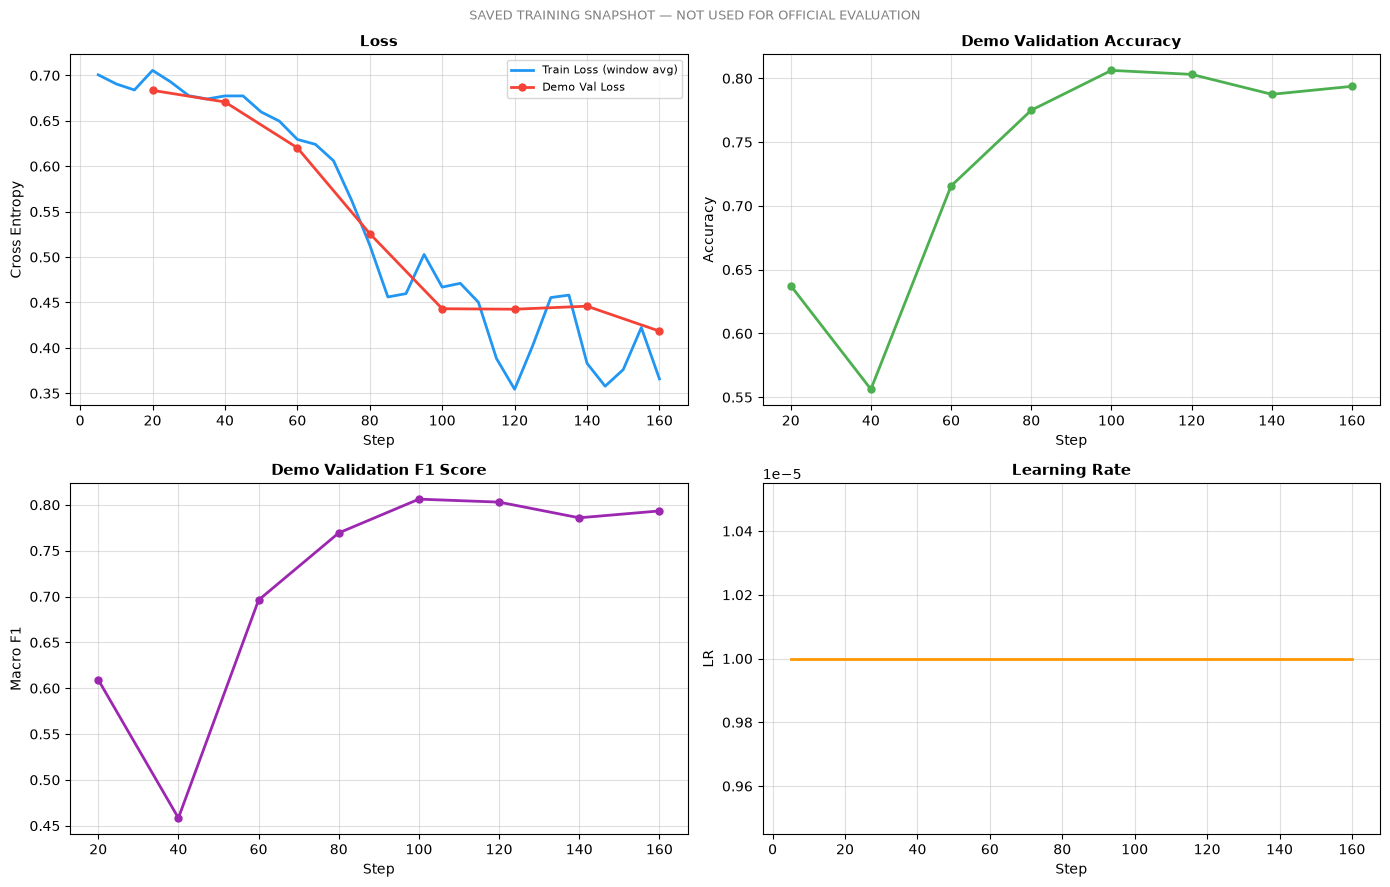

{'status': {'status': 'COMPLETED',
  'pid': 89722,
  'started_at': '2026-08-16T13:25:31.187548+00:00',
  'current_epoch': 2.0,
  'current_step': 160,
  'total_steps': 160,
  'last_update': '2026-08-16T13:25:53.921115+00:00',
  'error': None},
 'metric_records': 40}

In [9]:
from total_practice.practice_3.processing_own_phase.live_training_monitor import (
    monitor_live_training,
)

monitor_live_training()


## Phase 9 - Learning Curves & Overfitting

Inspect the saved epoch-level trajectories for all six clean experiments. The plots below are reconstructed from each run’s `training_history.json`; no static web dashboard or stale figure file is used.

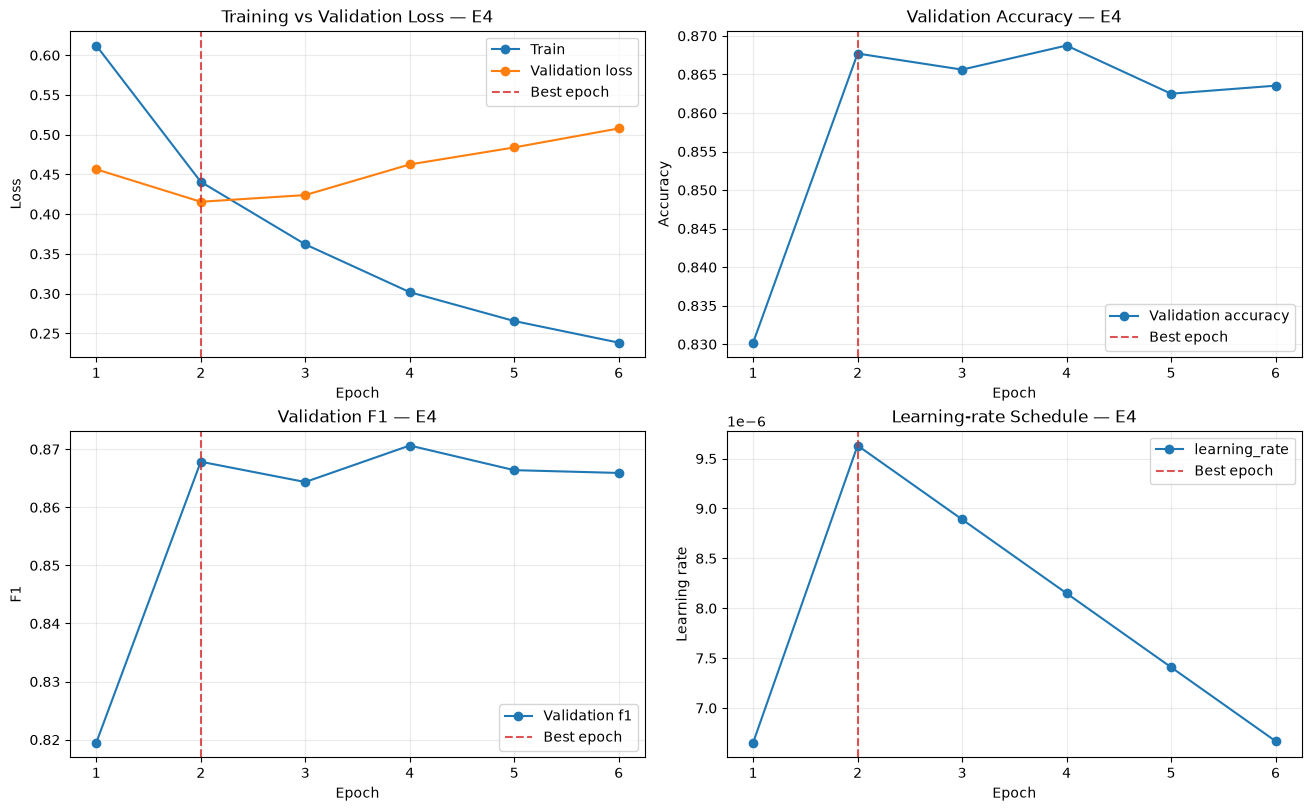

In [10]:
leader_id = visualization["validation_leader"]
leader = next(row for row in experiments if row["run_id"] == leader_id)
leader_history = pd.DataFrame(leader["history"])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
leader_plots = [
    ("train_loss", "eval_loss", "Training vs Validation Loss", "Loss"),
    (None, "eval_accuracy", "Validation Accuracy", "Accuracy"),
    (None, "eval_f1", "Validation F1", "F1"),
    (None, "learning_rate", "Learning-rate Schedule", "Learning rate"),
]
for axis, (train_column, eval_column, title, ylabel) in zip(axes.flat, leader_plots):
    if train_column:
        axis.plot(leader_history["epoch"], leader_history[train_column], marker="o", label="Train")
    axis.plot(leader_history["epoch"], leader_history[eval_column], marker="o", label=eval_column.replace("eval_", "Validation "))
    axis.axvline(leader["best_epoch"], color="#D62728", linestyle="--", alpha=0.8, label="Best epoch")
    axis.set(title=f"{title} — {leader['short_id']}", xlabel="Epoch", ylabel=ylabel)
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()


### Experiment Comparison — E1 to E6

Compare convergence, early-stopping behavior, and runtime across the clean experiment sequence using only the saved histories and summaries.

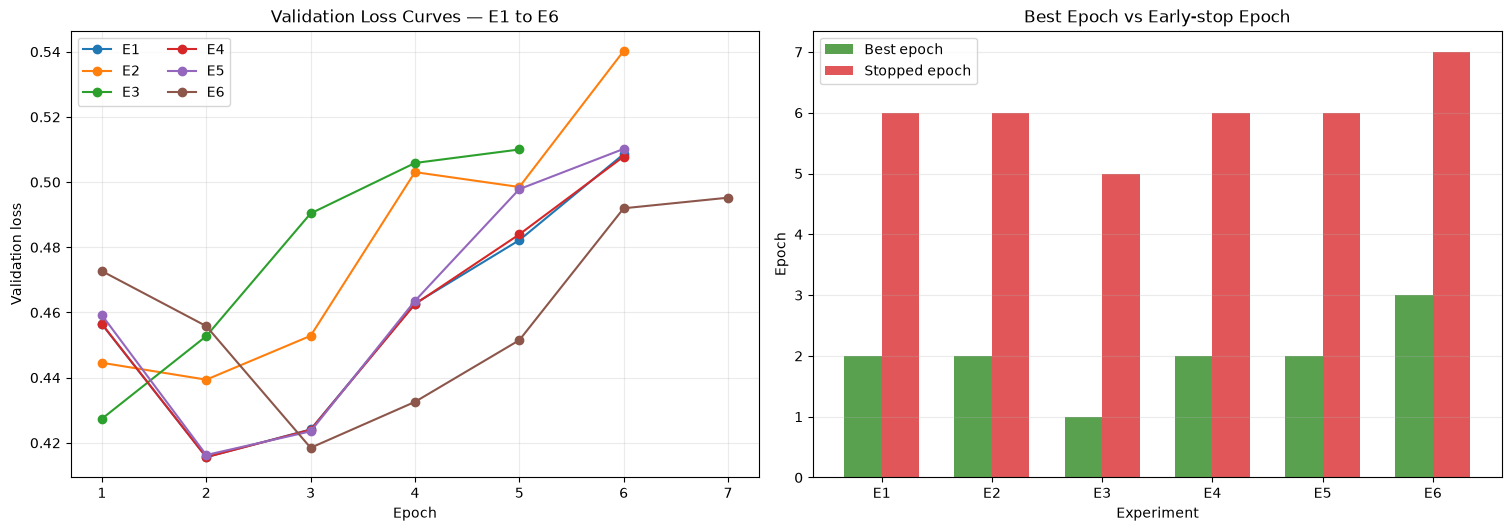

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)

for row in experiments:
    history = pd.DataFrame(row["history"])
    if history.empty:
        continue
    axes[0].plot(history["epoch"], history["eval_loss"], marker="o", label=row["short_id"])
axes[0].set(title="Validation Loss Curves — E1 to E6", xlabel="Epoch", ylabel="Validation loss")
axes[0].grid(alpha=0.25)
axes[0].legend(ncol=2)

comparison = pd.DataFrame(experiments)
x = np.arange(len(comparison))
width = 0.34
axes[1].bar(x - width / 2, comparison["best_epoch"], width, label="Best epoch", color="#59A14F")
axes[1].bar(x + width / 2, comparison["stopped_epoch"], width, label="Stopped epoch", color="#E15759")
axes[1].set(title="Best Epoch vs Early-stop Epoch", xlabel="Experiment", ylabel="Epoch", xticks=x, xticklabels=comparison["short_id"])
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()
plt.show()


## Phase 10 - Final Holdout Evaluation

Present a previously generated one-time Holdout evaluation. Missing artifacts remain pending; Run All never performs Holdout inference.

In [12]:
holdout = presentation["final_holdout"]
lock_artifact, metrics_artifact = holdout["winner_lock"], holdout["metrics"]
if lock_artifact["available"] and metrics_artifact["available"]:
    lock, metrics = lock_artifact["data"], metrics_artifact["data"]
    compare = pd.DataFrame([
        {"Metric": "Loss", "Validation": lock.get("best_val_loss"), "Holdout": metrics.get("holdout_loss")},
        {"Metric": "Accuracy", "Validation": lock.get("best_val_accuracy"), "Holdout": metrics.get("holdout_accuracy")},
        {"Metric": "F1", "Validation": lock.get("best_val_f1"), "Holdout": metrics.get("holdout_f1")},
    ])
    display(colored_table(compare, "Saved Validation vs Holdout Metrics"))
else:
    show_missing()


,Metric,Validation,Holdout
0,Loss,0.415604,0.353685
1,Accuracy,0.867708,0.854167
2,F1,0.867846,0.852321


## Phase 11 - Error Analysis

Present saved Holdout error-analysis tables and figures when available. Missing artifacts do not trigger prediction or evaluation.

### Final Holdout Confusion Matrix

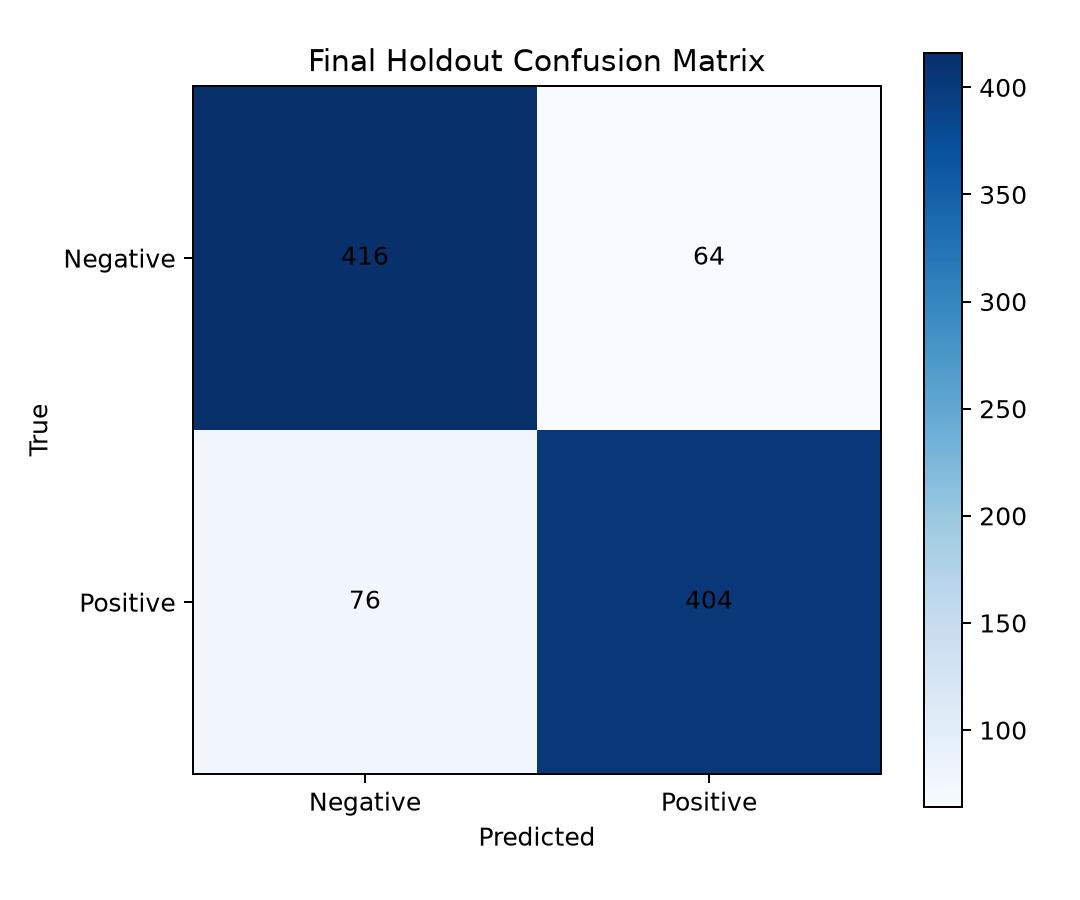

### Confidence Distribution

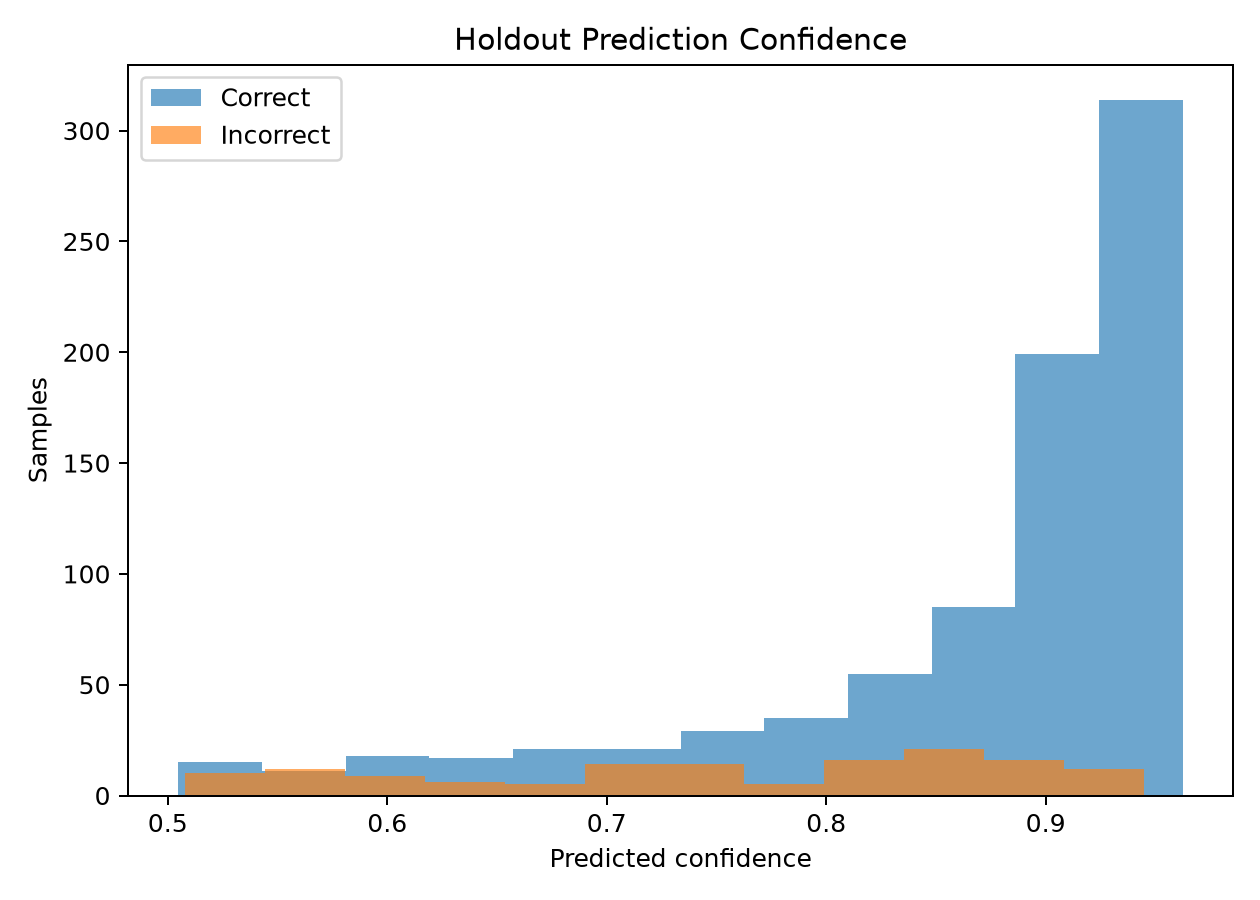

In [13]:
error_artifacts = presentation["error_analysis"]
for key, title in [("confusion_matrix", "Final Holdout Confusion Matrix"), ("confidence_figure", "Confidence Distribution")]:
    artifact = error_artifacts[key]
    display(Markdown(f"### {title}"))
    if artifact["available"]:
        display(Image(filename=artifact["path"]))
    else:
        show_missing()


In [14]:
errors_artifact = error_artifacts["errors"]
high_conf_artifact = error_artifacts["high_confidence_errors"]
if errors_artifact["available"]:
    errors_df = pd.DataFrame(errors_artifact["data"])
    display(colored_table(errors_df.head(6), "Saved Representative Errors"))
else:
    show_missing()
if high_conf_artifact["available"]:
    high_conf_df = pd.DataFrame(high_conf_artifact["data"])
    display(colored_table(high_conf_df.head(6), "Saved High-confidence Errors"))
else:
    show_missing()


,sample_index,text,true_label,predicted_label,logit_class_0,logit_class_1,probability_class_0,probability_class_1,predicted_confidence,correct
0,476,"'synthetic' is the best description of this well-meaning , beautifully produced film that sacrifices its promise for a high-powered star pedigree .",0,1,-1.4787530899047852,1.3631459474563599,0.05510158836841583,0.9448984265327454,0.9448984265327454,False
1,596,"whatever eyre's failings as a dramatist , he deserves credit for bringing audiences into this hard and bitter place .",0,1,-1.4531582593917847,1.2897635698318481,0.060487642884254456,0.9395123720169067,0.9395123720169067,False
2,828,"[hawn's character]is so bluntly written , without a trace of sentimentality , and so blisteringly defined , that every other character seems overlooked and underwritten .",1,0,1.4601821899414062,-1.247804045677185,0.9374963045120239,0.06250374019145966,0.9374963045120239,False
3,947,represents something very close to the nadir of the thriller/horror genre .,0,1,-1.2973003387451172,1.1440484523773193,0.08007349818944931,0.9199264645576477,0.9199264645576477,False
4,201,it's virtually impossible to like any of these despicable characters .,1,0,1.2552306652069092,-1.1454477310180664,0.9168790578842163,0.08312097936868668,0.9168790578842163,False
5,120,it's an often-cute film but either needs more substance to fill the time or some judicious editing .,1,0,1.2893978357315063,-1.1077946424484253,0.9166129231452942,0.08338703215122223,0.9166129231452942,False


,sample_index,text,true_label,predicted_label,logit_class_0,logit_class_1,probability_class_0,probability_class_1,predicted_confidence,correct
0,476,"'synthetic' is the best description of this well-meaning , beautifully produced film that sacrifices its promise for a high-powered star pedigree .",0,1,-1.4787530899047852,1.3631459474563599,0.05510158836841583,0.9448984265327454,0.9448984265327454,False
1,596,"whatever eyre's failings as a dramatist , he deserves credit for bringing audiences into this hard and bitter place .",0,1,-1.4531582593917847,1.2897635698318481,0.060487642884254456,0.9395123720169067,0.9395123720169067,False
2,828,"[hawn's character]is so bluntly written , without a trace of sentimentality , and so blisteringly defined , that every other character seems overlooked and underwritten .",1,0,1.4601821899414062,-1.247804045677185,0.9374963045120239,0.06250374019145966,0.9374963045120239,False
3,947,represents something very close to the nadir of the thriller/horror genre .,0,1,-1.2973003387451172,1.1440484523773193,0.08007349818944931,0.9199264645576477,0.9199264645576477,False
4,201,it's virtually impossible to like any of these despicable characters .,1,0,1.2552306652069092,-1.1454477310180664,0.9168790578842163,0.08312097936868668,0.9168790578842163,False
5,120,it's an often-cute film but either needs more substance to fill the time or some judicious editing .,1,0,1.2893978357315063,-1.1077946424484253,0.9166129231452942,0.08338703215122223,0.9166129231452942,False


## Phase 12 - Custom Inference

Present custom-inference predictions only when their saved artifact exists. The notebook never loads a model to generate replacements.

In [15]:
custom = presentation["custom_inference"]
if custom["available"]:
    custom_df = pd.DataFrame(custom["data"])
    display(colored_table(custom_df, "Saved Custom Inference Results", boolean_columns=["match_expected"]))
else:
    show_missing()


,sample_id,text,intended_category,expected_label,predicted_label,predicted_label_name,probability_negative,probability_positive,confidence,match_expected
0,custom_1,I absolutely loved this movie. The acting was excellent and the plot was engaging.,CLEAR_POSITIVE,1,1,Positive,0.060932788997888565,0.9390671253204346,0.9390671253204346,True
1,custom_2,This movie was boring and a complete waste of time. I fell asleep halfway through.,CLEAR_NEGATIVE,0,0,Negative,0.9383187294006348,0.06168125942349434,0.9383187294006348,True
2,custom_3,"I did not dislike the movie, but I also wouldn't say I enjoyed it.",NEGATION,,0,Negative,0.7821128964424133,0.21788711845874786,0.7821128964424133,
3,custom_4,"The acting was great, but the story was incredibly disappointing and contrived.",MIXED_SENTIMENT,,0,Negative,0.9318179488182068,0.0681820958852768,0.9318179488182068,
4,custom_5,"It is not perfect, but I would gladly watch it again on a rainy afternoon.",SUBTLE_POSITIVE,1,0,Negative,0.5430838465690613,0.45691612362861633,0.5430838465690613,False
5,custom_6,"The movie looks beautiful, although there is little else to recommend about it.",SUBTLE_NEGATIVE,0,1,Positive,0.4044118821620941,0.5955880880355835,0.5955880880355835,False
6,custom_7,I really expected more from this film given the cast.,AMBIGUOUS,,0,Negative,0.6633610725402832,0.3366389870643616,0.6633610725402832,
7,custom_8,"The beginning was excruciatingly slow, but the ending made the whole movie completely worthwhile.",CONTRAST,1,1,Positive,0.11557423323392868,0.8844258189201355,0.8844258189201355,True
8,custom_9,Not exactly what I was hoping for.,NEGATION,0,0,Negative,0.9052799344062805,0.09472008049488068,0.9052799344062805,True


## Phase 13 - Save / Reload Verification

Present saved persistence-verification evidence when available. The notebook never saves, reloads, or compares model weights itself.

In [16]:
verification = presentation["save_reload"]
if verification["available"]:
    verif = verification["data"]
    verification_df = pd.DataFrame([
        {"Metric": "Parameter Mismatches", "Value": verif.get("parameter_mismatch_count")},
        {"Metric": "Prediction Matches", "Value": f"{verif.get('prediction_match_count')} / {verif.get('sentences_compared')}"},
        {"Metric": "Probability Max Diff", "Value": verif.get("max_probability_difference")},
    ])
    display(colored_table(verification_df, "Saved Save / Reload Evidence"))
else:
    show_missing()


,Metric,Value
0,Parameter Mismatches,0
1,Prediction Matches,9 / 9
2,Probability Max Diff,0.000001
